In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt


# 1. set up and load data

In [2]:

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata = sc.read_h5ad(filename)

sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_scVI')
sc.tl.umap(adata)


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


# 2. Explore GMM across multiple k (num of components)


In [3]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1. Define the grid of number of GMM components to test
n_components_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

results = []

for n_comp in n_components_list:
    key = f'gmm_{n_comp}'
    # 2. Fit GMM on the UMAP coordinates
    gmm = GaussianMixture(n_components=n_comp, covariance_type='full', random_state=0)
    labels = gmm.fit_predict(adata.obsm['X_umap'])
    
    # store cluster labels in adata.obs if you like
    adata.obs[key] = labels.astype(str)
    
    n_clusters = n_comp
    sil = silhouette_score(adata.obsm['X_umap'], labels)
    
    # 3. Stability: mean ARI over 5 random 80% subsamples
    aris = []
    for _ in range(5):
        idx = np.random.choice(adata.n_obs, size=int(adata.n_obs*0.8), replace=False)
        sub = adata[idx]
        # re‐fit a fresh GMM on the subsample
        gmm_sub = GaussianMixture(n_components=n_comp, covariance_type='full', random_state=0)
        lab_sub = gmm_sub.fit_predict(sub.obsm['X_umap'])
        full_lab = labels[idx]
        aris.append(adjusted_rand_score(full_lab, lab_sub))
    ari_mean = np.mean(aris)
    
    results.append({
        'n_components': n_comp,
        'n_clusters': n_clusters,
        'silhouette': sil,
        'ARI_stability': ari_mean
    })

metrics = pd.DataFrame(results)
display(metrics)

,n_components,n_clusters,silhouette,ARI_stability
0,2,2,0.490655,0.975220
1,3,3,0.356275,0.967088
2,4,4,0.396733,0.790778
3,5,5,0.442410,0.971254
4,6,6,0.414632,0.778665
5,7,7,0.392830,0.739799
6,8,8,0.371373,0.668681
7,9,9,0.370572,0.709131
8,10,10,0.357474,0.610119


# 3. Visualize metrics
## 3.1 Resolution vs. Silhouette Score

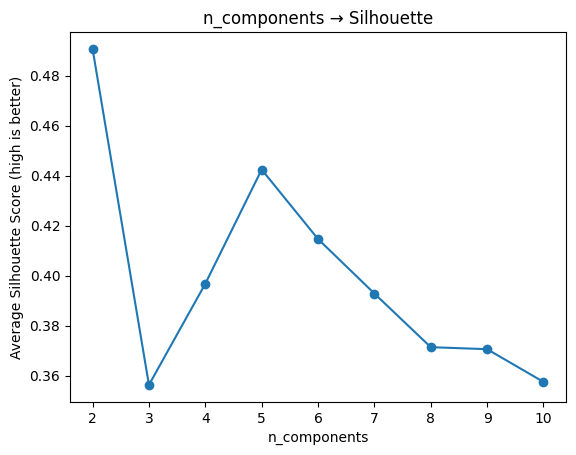

In [7]:
plt.figure()
plt.plot(metrics['n_components'], metrics['silhouette'], marker='o')
plt.xlabel('n_components')
plt.ylabel('Average Silhouette Score (high is better)')
plt.title('n_components → Silhouette')
plt.show()


## 3.2 Resolution vs. Number of Clusters

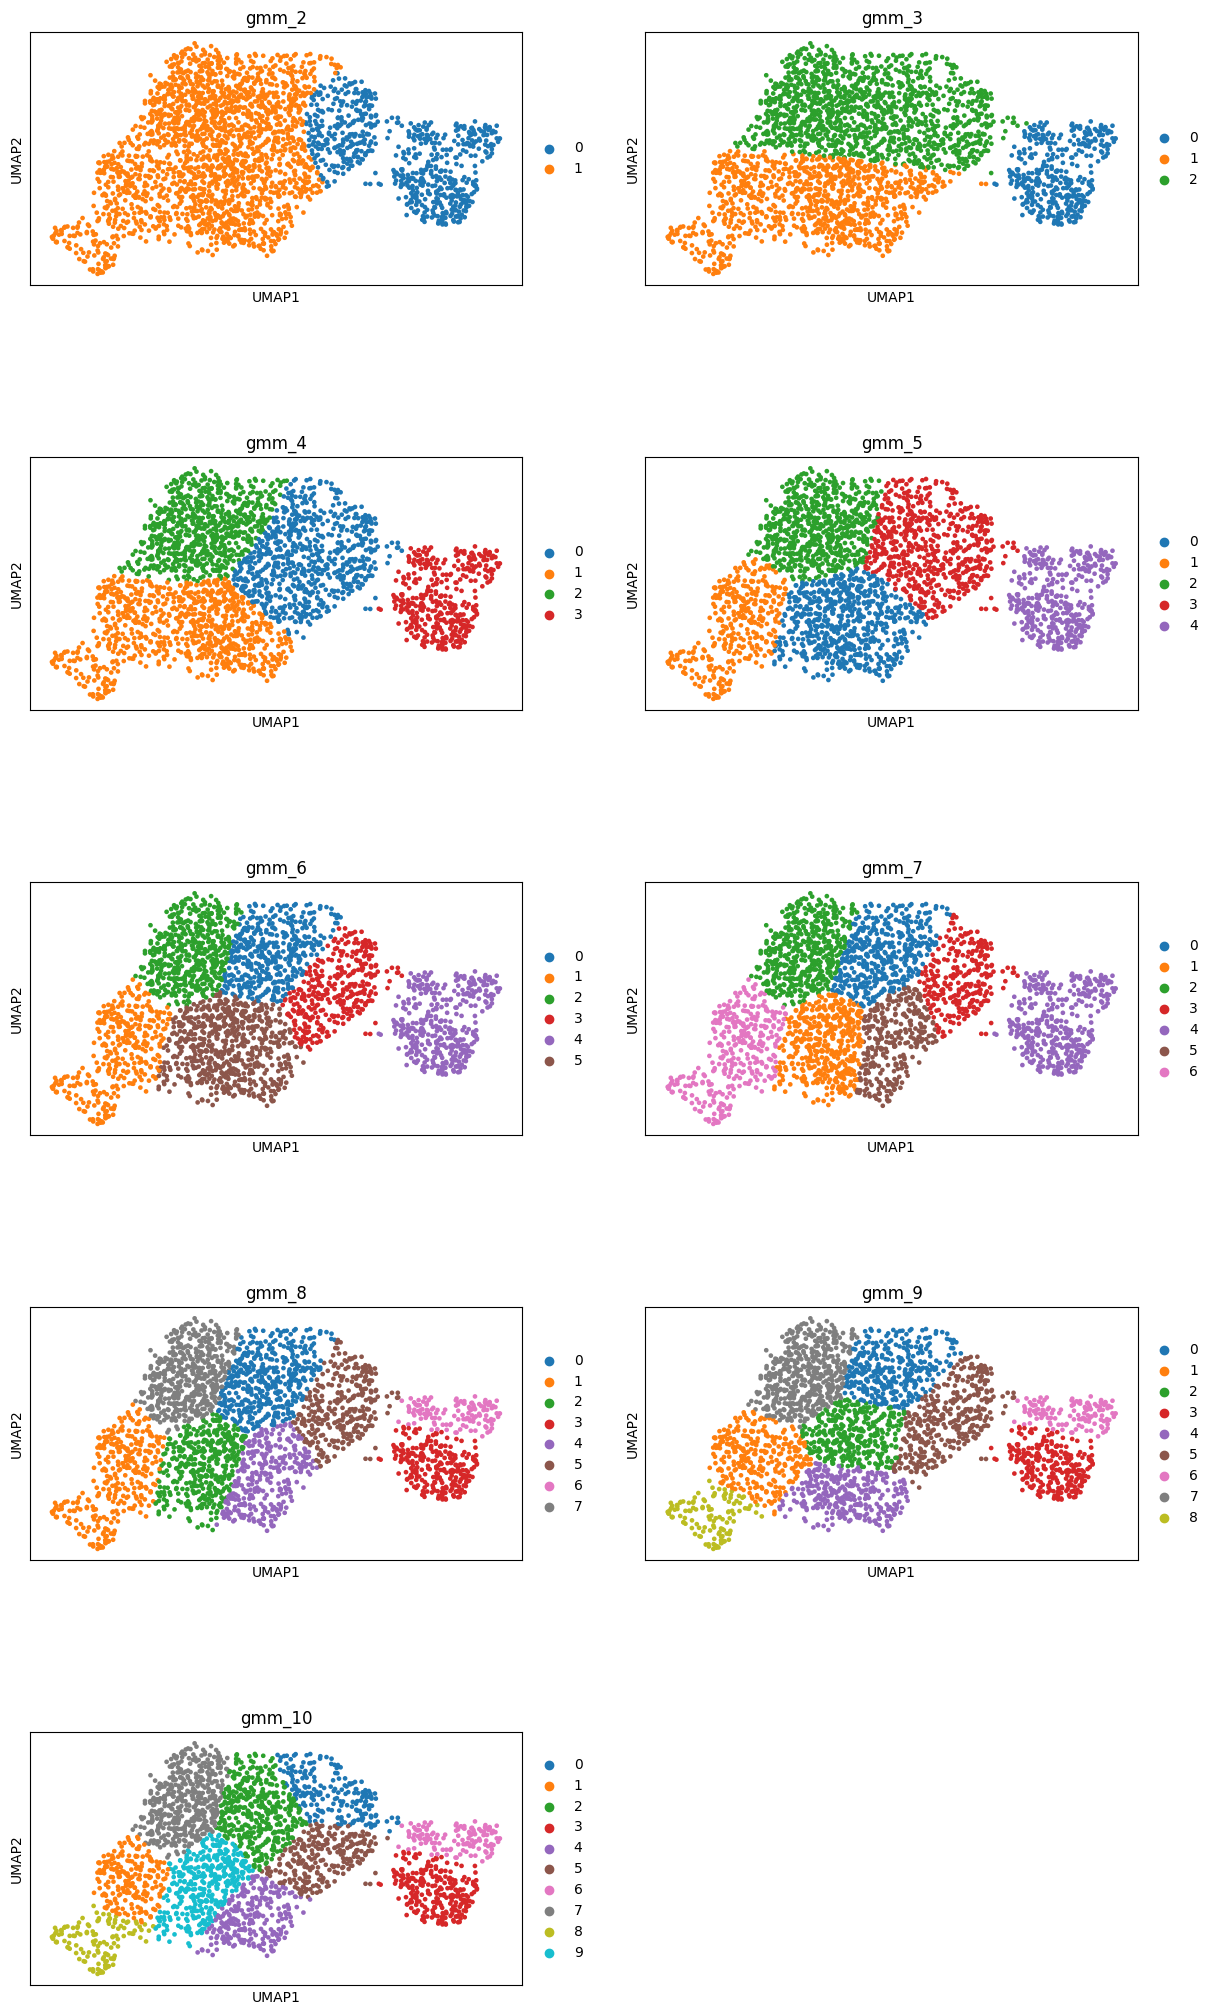

In [9]:
axes = sc.pl.umap(adata, color=[f'gmm_{k}' for k in n_components_list], show = False, ncols = 2)
for a in axes: a.set_aspect('equal')

# 3.3 Resolution vs. ARI (Stability, Adjusted Rand Index.)

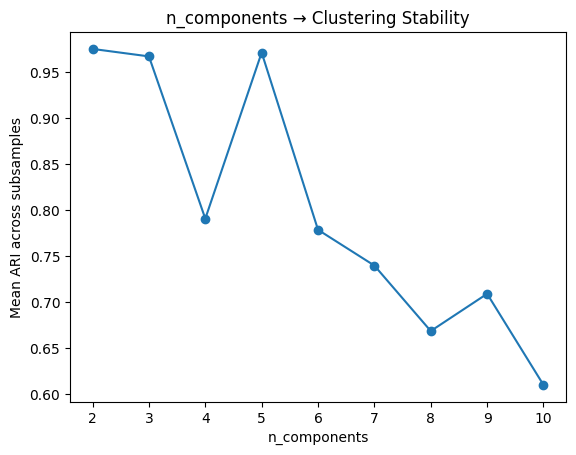

In [10]:
plt.figure()
plt.plot(metrics['n_components'], metrics['ARI_stability'], marker='o')
plt.xlabel('n_components')
plt.ylabel('Mean ARI across subsamples')
plt.title('n_components → Clustering Stability')
plt.show()


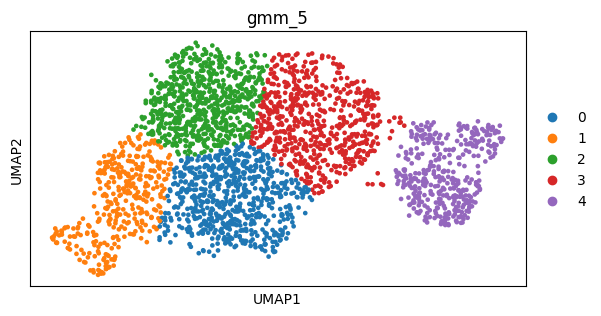

In [11]:
a = sc.pl.umap(adata, color='gmm_5', show = False)
a.set_aspect('equal')

# 5. consensus
1. take random 80 % subsamples of cells and re-cluster
2. check if we get (almost) the same assignments
3. build a consensus matrix with co-occurrence frequencies

In [15]:
n_comp = 5
n_cells = adata.n_obs
consensus = np.zeros((n_cells, n_cells))
n_runs = 10
n_comp = 5  # ← choose your number of GMM clusters here

for run in range(n_runs):
    # 1) subsample 80% of the cells
    idx = np.random.choice(n_cells, size=int(0.8 * n_cells), replace=False)
    coords_sub = adata.obsm['X_umap'][idx]
    
    # 2) fit GMM on the subsample UMAP coords
    gmm = GaussianMixture(n_components=n_comp,
                          covariance_type='full',
                          random_state=run)
    lab_sub = gmm.fit_predict(coords_sub)
    
    # 3) increment consensus counts for every pair in the same sub‐cluster
    for i_sub, ci in enumerate(idx):
        same = idx[lab_sub == lab_sub[i_sub]]
        consensus[ci, same] += 1

# 4) normalize to fraction of runs
consensus /= n_runs

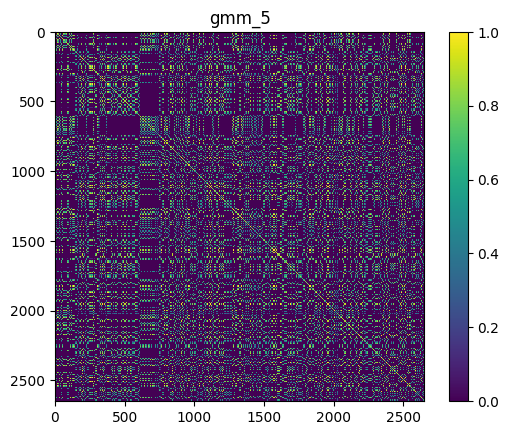

In [16]:
plt.imshow(consensus, interpolation = 'nearest')
plt.title(f'gmm_{n_comp}')
plt.colorbar()

### get the mean consensus score 

In [19]:
labels = adata.obs[f'gmm_{n_comp}'].astype('category').cat.codes.values
n = adata.n_obs
# consensus is an (n,n) numpy array
cluster_scores = {}
for cl in np.unique(labels):
    idx = np.where(labels == cl)[0]
    if len(idx) > 1:
        # extract the submatrix, exclude diagonal
        sub = consensus[np.ix_(idx, idx)]
        # sum of off-diagonals
        s = sub.sum() - sub.trace()
        count = len(idx)*(len(idx)-1)
        cluster_scores[cl] = s / count
    else:
        cluster_scores[cl] = np.nan  # singleton
print("Mean within-cluster consensus:", cluster_scores)
print('average:',np.sum(list(cluster_scores.values()))/len(cluster_scores))

Mean within-cluster consensus: {np.int8(0): np.float64(0.6132568168374452), np.int8(1): np.float64(0.6275933837222039), np.int8(2): np.float64(0.6234848128975281), np.int8(3): np.float64(0.6374312884336208), np.int8(4): np.float64(0.6385646645021644)}
average: 0.6280661932785925


# consensus across different ks
1. link:[Consensus Clustering: A Resampling-Based Method for Class Discovery and Visualization of Gene Expression Microarray Data](https://link.springer.com/article/10.1023/A:1023949509487)
2. [ConsensusClusterPlus](https://academic.oup.com/bioinformatics/article/26/12/1572/281699)



In [20]:

# 1) define your grid of GMM component counts
n_components_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
n_cells = adata.n_obs
n_runs = 10

consensus_scores = {}

for n_comp in n_components_list:
    # reset consensus matrix for this n_comp
    consensus = np.zeros((n_cells, n_cells))
    
    # 2) build consensus over subsamples
    for run in range(n_runs):
        idx = np.random.choice(n_cells, size=int(0.8 * n_cells), replace=False)
        coords_sub = adata.obsm['X_umap'][idx]
        
        # fit GMM on subsample
        gmm_sub = GaussianMixture(n_components=n_comp,
                                  covariance_type='full',
                                  random_state=run)
        lab_sub = gmm_sub.fit_predict(coords_sub)
        
        # increment co-cluster counts
        for i_sub, ci in enumerate(idx):
            same = idx[lab_sub == lab_sub[i_sub]]
            consensus[ci, same] += 1
    
    # normalize to fraction of runs
    consensus /= n_runs

    # 3) fit GMM on the full dataset to get “true” labels
    gmm_full = GaussianMixture(n_components=n_comp,
                               covariance_type='full',
                               random_state=0)
    full_labels = gmm_full.fit_predict(adata.obsm['X_umap'])
    
    # 4) compute mean within-cluster consensus
    cluster_scores = {}
    for cl in np.unique(full_labels):
        members = np.where(full_labels == cl)[0]
        if len(members) > 1:
            submat = consensus[np.ix_(members, members)]
            # off-diagonal sum
            total = submat.sum() - submat.trace()
            count = len(members) * (len(members) - 1)
            cluster_scores[cl] = total / count
        else:
            cluster_scores[cl] = np.nan  # singleton clusters
    
    # 5) average across clusters
    consensus_scores[n_comp] = np.nanmean(list(cluster_scores.values()))

# consensus_scores now maps n_components → mean within-cluster consensus
print(consensus_scores)

{2: np.float64(0.6235189873837754), 3: np.float64(0.6315078368776045), 4: np.float64(0.5421977826454278), 5: np.float64(0.6279557428264824), 6: np.float64(0.5652190915172935), 7: np.float64(0.4803726727059496), 8: np.float64(0.47587141335732264), 9: np.float64(0.4712890498715852), 10: np.float64(0.4405262149138364)}


Text(0.5, 1.0, 'Resolution → consensus scores')

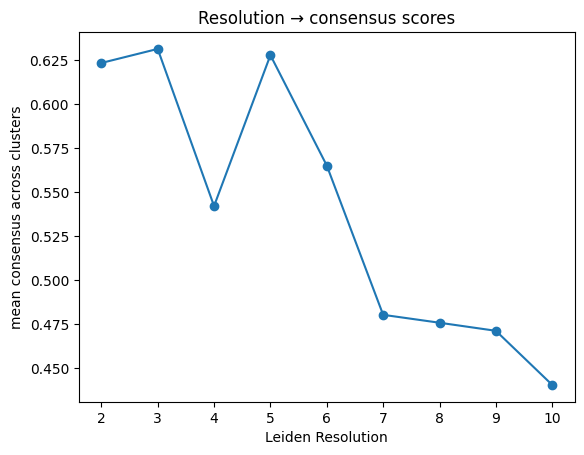

In [21]:
plt.plot(consensus_scores.keys(), consensus_scores.values(), '-o')
plt.xlabel('Leiden Resolution')
plt.ylabel('mean consensus across clusters')
plt.title('Resolution → consensus scores')


# 5. graph modularity

In [18]:
import igraph as ig

# build igraph from Scanpy’s connectivity
conn = adata.obsp['connectivities']
sources, targets = conn.nonzero()
g = ig.Graph(edges=list(zip(sources.tolist(), targets.tolist())), directed=False)

labels = adata.obs[f'leiden_{res}'].astype('category').cat.codes.tolist()
mod_score = g.modularity(labels)
print(f"Graph modularity at res={res}: {mod_score:.3f}")

Graph modularity at res=1.0: 0.645


# 6. DE genes

In [17]:
sc.tl.rank_genes_groups(adata, f'leiden_{res}', method='t-test')
# sc.pl.rank_genes_groups_heatmap(adata, n_genes=5)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 315 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


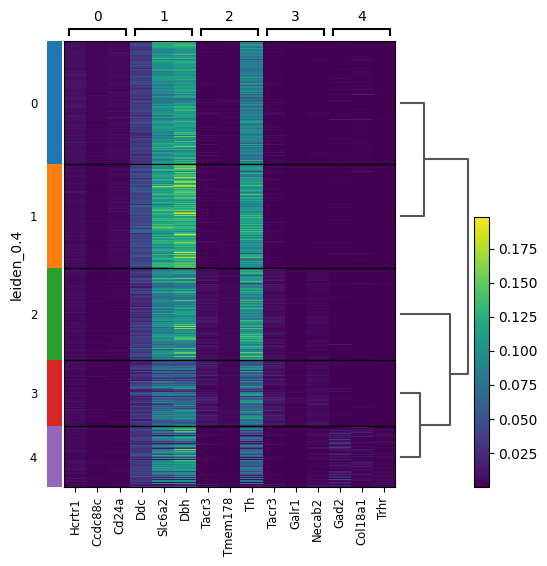

In [18]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=3)

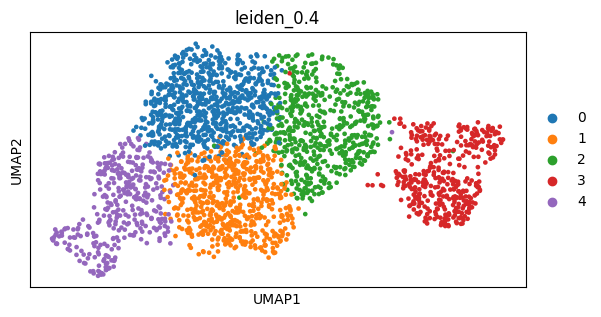

In [19]:
a = sc.pl.umap(adata, color=f'leiden_0.4', show = False)
a.set_aspect('equal')

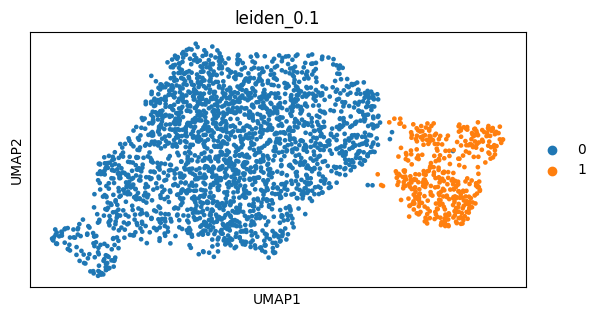

In [18]:
a = sc.pl.umap(adata, color=f'leiden_0.1', show = False)
a.set_aspect('equal')